**FORMACIÓN DEL BIOFILM (1 BACTERIA)**

*time-lapse*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, clear_output
import time


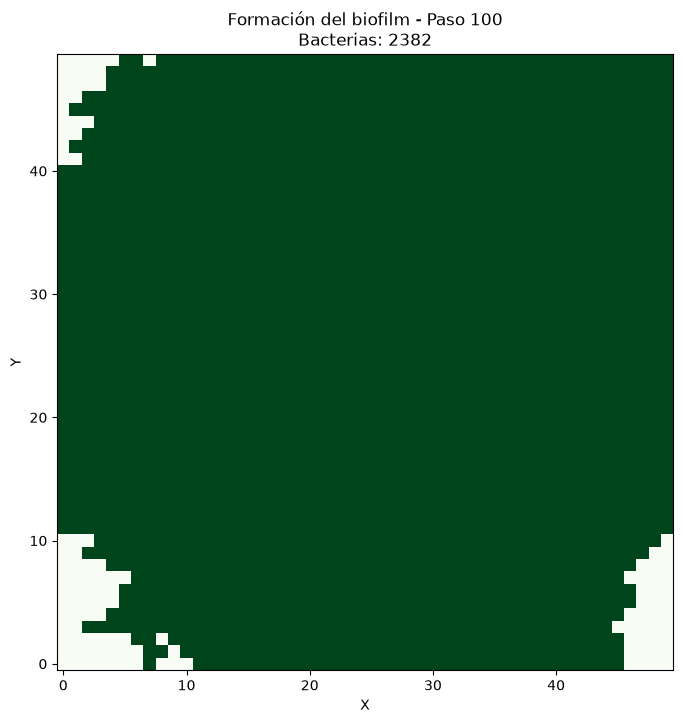

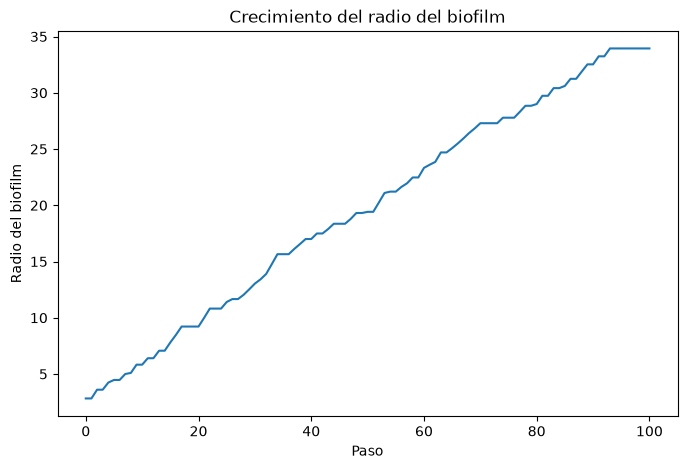

In [2]:
l = 50
b_0 = 5
div_prob = 0.3
steps = 100

lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] == 1:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    lattice[x, y] = 1

def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors

def divide_bacterium(x, y):
    neighbors = get_neighbors(x, y)
    free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
    if len(free_pos) == 0:         
        return False

    daughter_x, daughter_y = random.choice(free_pos) 

    lattice[daughter_x, daughter_y] = 1
    return True

lattice_history = []
blocked_bacteria = set()

for step in range(steps + 1): 

    clear_output(wait=True)
    lattice_history.append(lattice.copy())

    plt.figure(figsize=(8, 8))

    plt.imshow(lattice, origin="lower", cmap="Greens", vmin=0, vmax=1)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacterias: {np.sum(lattice)}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.05)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice == 1))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if (x, y) in blocked_bacteria:
            continue

        neighbors = get_neighbors(x, y)

        free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
        if len(free_pos) == 0:
            blocked_bacteria.add((x, y))
            continue
        if random.random() < div_prob:
            daughter_x, daughter_y = random.choice(free_pos)
            lattice[daughter_x, daughter_y] = 1
      


def calculate_radius(lattice):
    bacteria_positions = np.argwhere(lattice == 1)

    if len(bacteria_positions) == 0:
        return 0

    distances = []

    for x, y in bacteria_positions:
        distance = np.sqrt((x - center)**2 + (y - center)**2)
        distances.append(distance)

    return max(distances)

radius_history = []
for lattice_steps in lattice_history:

    radius = calculate_radius(lattice_steps)
    radius_history.append(radius)

plt.figure(figsize=(8, 5))

plt.plot(range(step + 1), radius_history)

plt.xlabel("Paso")
plt.ylabel("Radio del biofilm")
plt.title("Crecimiento del radio del biofilm")

plt.show()

    

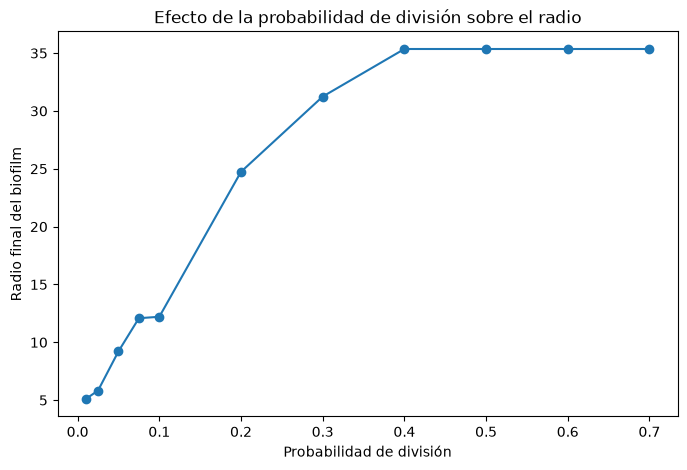

In [3]:
l = 50
b_0 = 5
steps = 100
div_prob_values = [0.01, 0.025, 0.05, 0.075, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

lattice = np.zeros((l, l), dtype=int)
center = l // 2

def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors

def calculate_radius(lattice):
    bacteria_positions = np.argwhere(lattice == 1)

    if len(bacteria_positions) == 0:
        return 0

    distances = []

    for x, y in bacteria_positions:
        distance = np.sqrt((x - center)**2 + (y - center)**2)
        distances.append(distance)

    return max(distances)

final_radius = []


for div_prob in div_prob_values:
    lattice = np.zeros((l, l), dtype=int)
    blocked_bacteria = set()
    for i in range(b_0):

        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)

        while lattice[x, y] == 1:

            x = center + random.randint(-2, 2)
            y = center + random.randint(-2, 2)

        lattice[x, y] = 1

    for step in range(steps):
        bacteria_positions = list(zip(*np.where(lattice == 1)))
        random.shuffle(bacteria_positions)
        for x, y in bacteria_positions: 
                if (x, y) in blocked_bacteria:
                    continue
        
                neighbors = get_neighbors(x, y)
        
                free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
                if len(free_pos) == 0:
                    blocked_bacteria.add((x, y))
                    continue
                
                if random.random() < div_prob:
                    daughter_x, daughter_y = random.choice(free_pos)
                    lattice[daughter_x, daughter_y] = 1
                    
    radius = calculate_radius(lattice)
    final_radius.append(radius)

plt.figure(figsize=(8, 5))

plt.plot(div_prob_values, final_radius, marker="o")

plt.xlabel("Probabilidad de división")
plt.ylabel("Radio final del biofilm")
plt.title("Efecto de la probabilidad de división sobre el radio")

plt.show()


**FORMACIÓN DEL BIOFILM (2 BACTERIAS) - NEUTRALISMO**

*time-lapse*

Se ha de arreglar. No es esto.

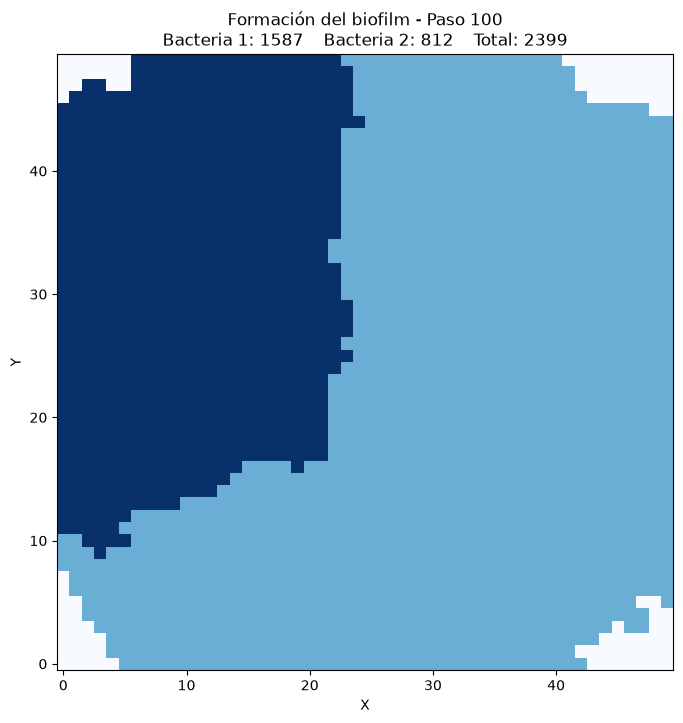

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import display, clear_output
import time

l = 50
b_0 = 6
div_prob = 0.3
steps = 100

lattice = np.zeros((l, l), dtype=int)
center = l // 2

for i in range(b_0):
    x = center + random.randint(-2, 2)
    y = center + random.randint(-2, 2)
    while lattice[x, y] != 0:
        x = center + random.randint(-2, 2)
        y = center + random.randint(-2, 2)
    if random.random() < 0.5:
        lattice[x, y] = 1
    else:
        lattice[x, y] = 2

def get_neighbors(x, y):
    neighbors = []
    if x > 0:
        neighbors.append((x - 1, y))
    if x < l - 1:
        neighbors.append((x + 1, y))
    if y > 0:
        neighbors.append((x, y - 1))
    if y < l - 1:
        neighbors.append((x, y + 1))
    return neighbors
    

def divide_bacterium(x, y):
    bacteria_type = lattice[x, y]
    neighbors = get_neighbors(x, y)
    free_pos = [(nx, ny) for nx, ny in neighbors if lattice[nx, ny] == 0]
    if len(free_pos) == 0:
        return

    daughter_x, daughter_y = random.choice(free_pos)

    lattice[daughter_x, daughter_y] = bacteria_type


for step in range(steps + 1): 
    clear_output(wait=True)

    bacteria_1 = np.sum(lattice == 1)
    bacteria_2 = np.sum(lattice == 2)
    total_bacteria = bacteria_1 + bacteria_2

    plt.figure(figsize=(8, 8))

    plt.imshow(lattice, origin="lower", cmap="Blues", vmin=0, vmax=2)

    plt.xlim(-0.5, l - 0.5)
    plt.ylim(-0.5, l - 0.5)

    plt.title( 
        f"Formación del biofilm - Paso {step}\n" 
        f"Bacteria 1: {bacteria_1}    "
        f"Bacteria 2: {bacteria_2}    "
        f"Total: {total_bacteria}" 
    ) 
    plt.xlabel("X") 
    plt.ylabel("Y") 
    plt.show()

    time.sleep(0.1)
    if step == steps:
        break

    bacteria_positions = list(zip(*np.where(lattice != 0))) 
    random.shuffle(bacteria_positions) 
    for x, y in bacteria_positions: 
        if lattice[x, y] != 0:
            if random.random() < div_prob:
                divide_bacterium(x, y)